In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [48]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
df = pd.read_csv('/content/SMSSpamCollection.unknown',
                 sep="\t", names=["label", "message"])

In [7]:
print("Dataset shape:", df.shape)
print("First 5 rows:\n", df.head())


Dataset shape: (5572, 2)
First 5 rows:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [8]:
X = df["message"]
y = df["label"]
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (5572,) y shape: (5572,)


In [9]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))
nlp = spacy.load("en_core_web_sm")


In [10]:
def clean_text(text):
      text = re.sub(r'\d+|\W+', ' ', text)
      text = text.lower()
      return text

df["cleaned"] = df["message"].apply(clean_text)


In [11]:
df["tokens"] = df["cleaned"].apply(word_tokenize)
df["stems"] = df["tokens"].apply(lambda tokens: [ps.stem(w) for w in tokens if w not in stop_words])

In [12]:
df["tokens"] = df["cleaned"].apply(lambda text: [token.text for token in nlp(text)])
df["stems"] = df["tokens"].apply(lambda tokens: [ps.stem(w) for w in tokens if w not in stop_words])

In [49]:
# Removed: nltk.download('punkt_tab') - this appears to be an invalid package.

In [14]:
_stems = [w for stems in df["stems"] for w in stems]
freq_dist = nltk.FreqDist(_stems)
print("Top 10 frequent stems:", freq_dist.most_common(10))

Top 10 frequent stems: [('  ', 2366), ('u', 1228), (' ', 1102), ('call', 695), ('go', 462), ('get', 458), ('ur', 391), ('nt', 349), ('gt', 318), ('lt', 316)]


In [15]:
def spacy_process(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc if token.is_alpha and token.pos_ in ["NOUN","VERB"]]
    return lemmas

In [16]:
df["lemmas"] = df["cleaned"].apply(spacy_process)
all_lemmas = [w for lem in df["lemmas"] for w in lem]
lemma_freq = nltk.FreqDist(all_lemmas)
print("Top 10 frequent lemmas:", lemma_freq.most_common(10))


Top 10 frequent lemmas: [('call', 689), ('get', 662), ('go', 616), ('have', 537), ('s', 414), ('do', 349), ('come', 325), ('m', 307), ('day', 290), ('know', 286)]


In [17]:
pos_counts = {}
for text in df["cleaned"].sample(100):
    doc = nlp(text)
    for token in doc:
        pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1

print("POS Frequency:", pos_counts)

POS Frequency: {'INTJ': 30, 'X': 10, 'ADP': 124, 'DET': 69, 'NOUN': 306, 'ADV': 79, 'PRON': 248, 'AUX': 96, 'VERB': 262, 'PART': 42, 'SCONJ': 45, 'ADJ': 101, 'CCONJ': 29, 'PROPN': 152, 'SPACE': 72, 'NUM': 3, 'PUNCT': 1}


In [18]:
verbs = [t.lemma_ for doc in df["cleaned"].apply(nlp) for t in doc if t.pos_=="VERB"]
adjs  = [t.lemma_ for doc in df["cleaned"].apply(nlp) for t in doc if t.pos_=="ADJ"]


In [19]:
verb_freq = nltk.FreqDist(verbs).most_common(10)
adj_freq  = nltk.FreqDist(adjs).most_common(10)

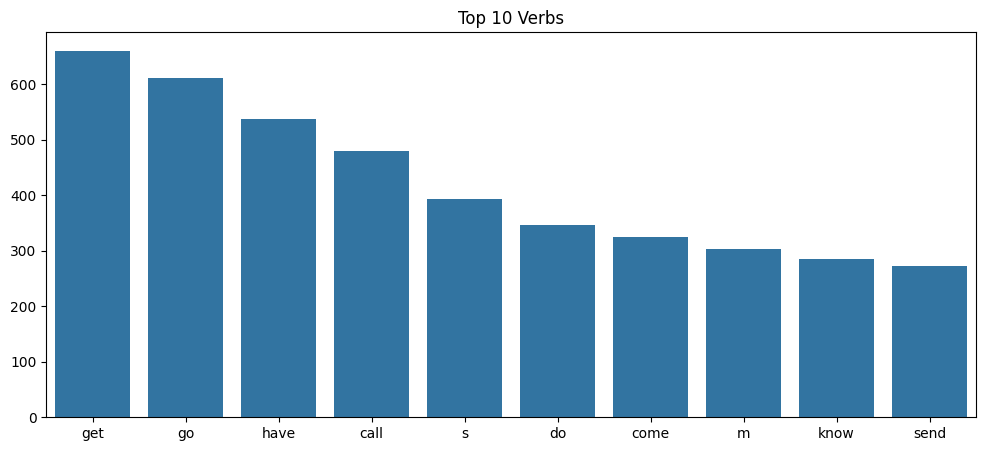

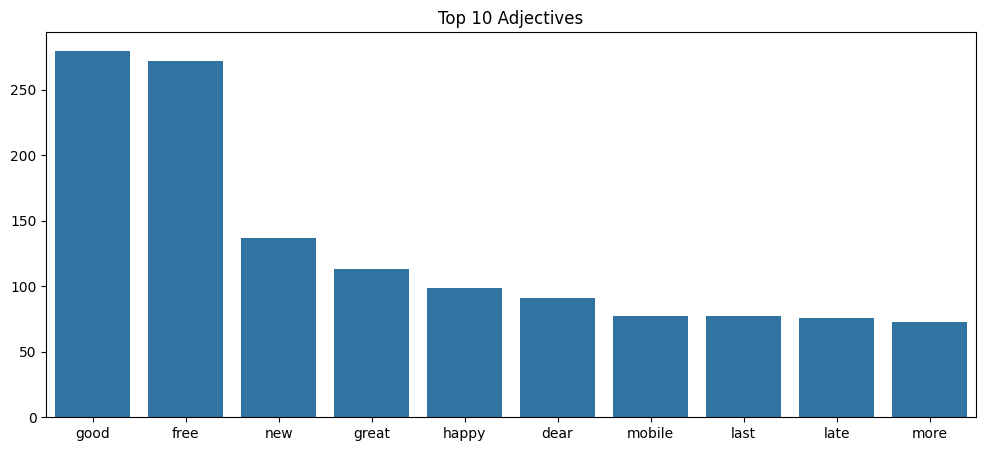

In [20]:
plt.figure(figsize=(12,5))
sns.barplot(x=[v[0] for v in verb_freq], y=[v[1] for v in verb_freq])
plt.title("Top 10 Verbs")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=[a[0] for a in adj_freq], y=[a[1] for a in adj_freq])
plt.title("Top 10 Adjectives")
plt.show()

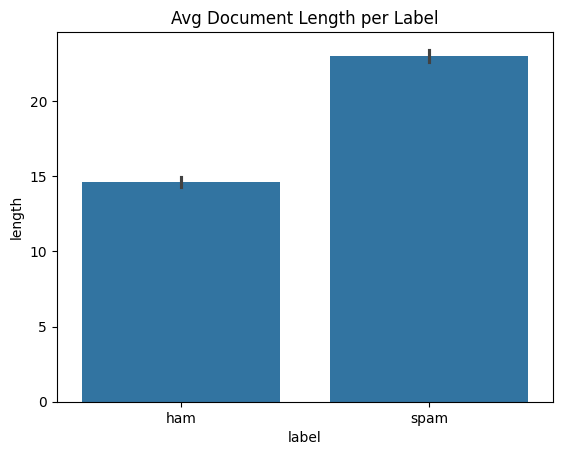

In [21]:
df["length"] = df["cleaned"].apply(lambda x: len(x.split()))
sns.barplot(x="label", y="length", data=df)
plt.title("Avg Document Length per Label")
plt.show()

In [22]:
cv = CountVectorizer(ngram_range=(1,2))
X_cv = cv.fit_transform(df["cleaned"])
print("Vocabulary size:", len(cv.vocabulary_))


Vocabulary size: 48084


In [23]:
sum_words = X_cv.sum(axis=0)
words_freq = [(w, sum_words[0, i]) for w, i in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
print("Most common bigrams/unigrams:", words_freq[:10])

Most common bigrams/unigrams: [('to', np.int64(2253)), ('you', np.int64(2247)), ('the', np.int64(1343)), ('and', np.int64(980)), ('in', np.int64(907)), ('is', np.int64(897)), ('me', np.int64(808)), ('my', np.int64(767)), ('it', np.int64(752)), ('for', np.int64(711))]


In [24]:
tfidf = TfidfVectorizer(stop_words="english")
X_tfidf = tfidf.fit_transform(df["cleaned"])

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


In [25]:
models = {
      "Logistic Regression": LogisticRegression(max_iter=500),
       "SVM": SVC(),
       "Random Forest": RandomForestClassifier()
}


In [26]:
for name, model in models.items():
      model.fit(X_train, y_train)
      preds = model.predict(X_test)
      print(f"\n{name} Performance:")
      print("Accuracy:", accuracy_score(y_test, preds))
      print("Precision:", precision_score(y_test, preds, pos_label="spam"))
      print("Recall:", recall_score(y_test, preds, pos_label="spam"))
      print("F1:", f1_score(y_test, preds, pos_label="spam"))



Logistic Regression Performance:
Accuracy: 0.9650224215246637
Precision: 1.0
Recall: 0.738255033557047
F1: 0.8494208494208494

SVM Performance:
Accuracy: 0.9757847533632287
Precision: 1.0
Recall: 0.8187919463087249
F1: 0.9003690036900369

Random Forest Performance:
Accuracy: 0.979372197309417
Precision: 1.0
Recall: 0.8456375838926175
F1: 0.9163636363636364


In [27]:
max_words = 5000
max_len = 100

In [28]:
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["cleaned"])
X_seq = tokenizer.texts_to_sequences(df["cleaned"])
X_pad = pad_sequences(X_seq, maxlen=max_len)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, (y=="spam").astype(int),
                                                    test_size=0.2, random_state=42)

In [50]:
mlp = Sequential([
      Embedding(max_words, 32),
      GlobalMaxPooling1D(),
      Dense(10, activation="relu"),
      Dense(1, activation="sigmoid")
])
mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
mlp.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8679 - loss: 0.4064 - val_accuracy: 0.8576 - val_loss: 0.3901
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8679 - loss: 0.3238 - val_accuracy: 0.8576 - val_loss: 0.2794
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9181 - loss: 0.1768 - val_accuracy: 0.9496 - val_loss: 0.1469


In [51]:
cnn = Sequential([
      Embedding(max_words, 32),
      Conv1D(64, 5, activation="relu"),
      GlobalMaxPooling1D(),
      Dense(1, activation="sigmoid")
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8525 - loss: 0.3919 - val_accuracy: 0.8688 - val_loss: 0.2395
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9717 - loss: 0.0941 - val_accuracy: 0.9765 - val_loss: 0.0844
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9896 - loss: 0.0306 - val_accuracy: 0.9809 - val_loss: 0.0735


In [52]:
bilstm = Sequential([
      Embedding(max_words, 32),
      Bidirectional(LSTM(32)),
      Dense(1, activation="sigmoid")
])
bilstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
bilstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8987 - loss: 0.2696 - val_accuracy: 0.9675 - val_loss: 0.1189
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9854 - loss: 0.0614 - val_accuracy: 0.9731 - val_loss: 0.0874
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9927 - loss: 0.0300 - val_accuracy: 0.9742 - val_loss: 0.0790


In [33]:
# Create the 'cleaned' column
df['cleaned'] = df['message'].apply(clean_text)
print("Cleaned column created successfully.")
print(df.head())


Cleaned column created successfully.
  label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                             cleaned  \
0  go until jurong point crazy available only in ...   
1                           ok lar joking wif u oni    
2  free entry in   a wkly comp to win fa cup fina...   
3       u dun say so early hor u c already then say    
4  nah i don t think he goes to usf he lives arou...   

                                              tokens  \
0  [go, until, jurong, point, crazy, available, o...   
1                     [ok, lar, joking, wif, u, oni]   
2  [free, entry, in,   , a, wkly, comp, to, win, ...   
3  [u, dun, say, so, early, h

word2vec+lstm & glove+lstm

In [59]:
# ============================================
# 🌐 WORD2VEC + LSTM
# ============================================
!pip install gensim --quiet
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer # Ensure Keras Tokenizer is imported
from tensorflow.keras.preprocessing.sequence import pad_sequences # Ensure pad_sequences is imported

print("\nTraining Word2Vec-LSTM Model...")

# Re-create a Keras Tokenizer instance specific to this cell
# to avoid conflicts with Hugging Face tokenizers later.
# Assume max_words and df["cleaned"] are available from previous cells.
local_keras_tokenizer = Tokenizer(num_words=max_words)
local_keras_tokenizer.fit_on_texts(df["cleaned"])
local_vocab_size = len(local_keras_tokenizer.word_index) + 1

# Prepare sequences using this local Keras tokenizer
X_seq_local = local_keras_tokenizer.texts_to_sequences(df["cleaned"])
X_pad_local = pad_sequences(X_seq_local, maxlen=max_len)

# Re-split data based on the locally padded sequences
from sklearn.model_selection import train_test_split
X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
    X_pad_local, (y=="spam").astype(int), test_size=0.2, random_state=42
)

tokenized = [text.split() for text in df["cleaned"]]
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1, workers=4)
embedding_matrix = np.zeros((local_vocab_size, 100)) # Use local_vocab_size
for word, i in local_keras_tokenizer.word_index.items(): # Use local_keras_tokenizer
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

w2v_lstm = Sequential([
    Embedding(local_vocab_size, 100, weights=[embedding_matrix], trainable=False),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
w2v_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
w2v_lstm.fit(X_train_local, y_train_local, epochs=3, batch_size=32, validation_split=0.2)
loss, acc = w2v_lstm.evaluate(X_test_local, y_test_local, verbose=0)
print(f"\nWord2Vec-LSTM Test Accuracy: {acc:.4f}")

# ============================================
# 🌍 GloVe + LSTM
# ============================================
print("\nTraining GloVe-LSTM Model...")

# Download and unzip GloVe embeddings if not already present
!wget -nc http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q -n glove.6B.zip -d /content/

glove_path = '/content/glove.6B.100d.txt'
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix_glove = np.zeros((local_vocab_size, 100)) # Use local_vocab_size
for word, i in local_keras_tokenizer.word_index.items(): # Use local_keras_tokenizer
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix_glove[i] = embedding_vector

glove_lstm = Sequential([
    Embedding(local_vocab_size, 100, weights=[embedding_matrix_glove], trainable=False),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
glove_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
glove_lstm.fit(X_train_local, y_train_local, epochs=3, batch_size=32, validation_split=0.2)
loss, acc = glove_lstm.evaluate(X_test_local, y_test_local, verbose=0)
print(f"\nGloVe-LSTM Test Accuracy: {acc:.4f}")


Training Word2Vec-LSTM Model...
Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 460ms/step - accuracy: 0.8676 - loss: 0.3523 - val_accuracy: 0.8711 - val_loss: 0.2972
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 75s 401ms/step - accuracy: 0.8875 - loss: 0.2670 - val_accuracy: 0.8834 - val_loss: 0.2714
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 82s 399ms/step - accuracy: 0.8999 - loss: 0.2481 - val_accuracy: 0.8812 - val_loss: 0.2752

Word2Vec-LSTM Test Accuracy: 0.9013

Training GloVe-LSTM Model...
File ‘glove.6B.zip’ already there; not retrieving.

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 43s 358ms/step - accuracy: 0.9083 - loss: 0.2481 - val_accuracy: 0.9484 - val_loss: 0.1204
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 355ms/step - accuracy: 0.9647 - loss: 0.1153 - val_accuracy: 0.9608 - val_loss: 0.1013
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 39s 352ms/step - accuracy: 0.9675 - loss: 0.0925 - val_accuracy: 0.9664 - val_loss: 0.0909

GloVe-LSTM Test Accuracy: 0.9812


In [35]:
!ls /content/

glove.6B.100d.txt  glove.6B.300d.txt  glove.6B.zip  SMSSpamCollection.unknown
glove.6B.200d.txt  glove.6B.50d.txt   sample_data


In [36]:
from gensim.models import Word2Vec

In [37]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d /content/

--2026-05-15 08:27:18--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-15 08:27:18--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-15 08:27:18--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [38]:
import pandas as pd

In [39]:
df = pd.read_csv('/content/SMSSpamCollection.unknown',
                 sep="\t", names=["label", "message"])

In [40]:
!pip install gensim

confusion matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step


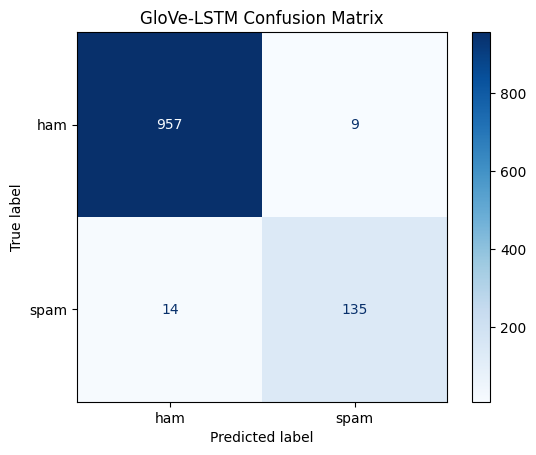


Classification Report (GloVe-LSTM):

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [41]:
# ============================================
# 📊 Confusion Matrix for Deep Model
# ============================================
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = (glove_lstm.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues")
plt.title("GloVe-LSTM Confusion Matrix")
plt.show()

print("\nClassification Report (GloVe-LSTM):\n")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

In [56]:
# Re-run the cell to define glove_lstm

# Re-initialize the Keras Tokenizer and vocab_size to avoid conflicts with Hugging Face tokenizers
from tensorflow.keras.preprocessing.text import Tokenizer
# Assuming max_words and df["cleaned"] are correctly defined in previous cells
keras_tokenizer = Tokenizer(num_words=max_words)
keras_tokenizer.fit_on_texts(df["cleaned"])
keras_vocab_size = len(keras_tokenizer.word_index) + 1

# Ensure GloVe embeddings are present
!wget -nc http://nlp.stanford.edu/data/glove.6B.zip # -nc means 'no clobber', won't re-download if exists
!unzip -q -n glove.6B.zip -d /content/ # -n means 'never overwrite existing files'

print("\nTraining GloVe-LSTM Model...")
glove_path = '/content/glove.6B.100d.txt'
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix_glove = np.zeros((keras_vocab_size, 100))
for word, i in keras_tokenizer.word_index.items(): # Use keras_tokenizer
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix_glove[i] = embedding_vector

glove_lstm = Sequential([
    Embedding(keras_vocab_size, 100, weights=[embedding_matrix_glove], trainable=False),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
glove_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
glove_lstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
loss, acc = glove_lstm.evaluate(X_test, y_test, verbose=0)
print(f"\nGloVe-LSTM Test Accuracy: {acc:.4f}")

File ‘glove.6B.zip’ already there; not retrieving.


Training GloVe-LSTM Model...
Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 44s 360ms/step - accuracy: 0.9119 - loss: 0.2353 - val_accuracy: 0.9451 - val_loss: 0.1502
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 42s 379ms/step - accuracy: 0.9647 - loss: 0.1108 - val_accuracy: 0.9630 - val_loss: 0.0943
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 85s 403ms/step - accuracy: 0.9672 - loss: 0.0945 - val_accuracy: 0.9675 - val_loss: 0.0901

GloVe-LSTM Test Accuracy: 0.9785


precision

In [43]:
from sklearn.metrics import precision_score

models = ['Word2Vec-LSTM', 'GloVe-LSTM']

# Get predictions from the trained models
y_pred_word2vec = (w2v_lstm.predict(X_test) > 0.5).astype(int)
y_pred_glove = (glove_lstm.predict(X_test) > 0.5).astype(int)

y_preds = [y_pred_word2vec, y_pred_glove]

for model, pred in zip(models, y_preds):
    prec = precision_score(y_test, pred, average='binary', pos_label=1)
    print(f"{model} Precision: {prec:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step
Word2Vec-LSTM Precision: 0.7035
GloVe-LSTM Precision: 0.9683


recall

In [44]:
from sklearn.metrics import recall_score

models = ['Word2Vec-LSTM', 'GloVe-LSTM']
y_preds = [y_pred_word2vec, y_pred_glove]

for model, pred in zip(models, y_preds):
    rec = recall_score(y_test, pred, average='binary', pos_label=1)
    print(f"{model} Recall: {rec:.4f}")

Word2Vec-LSTM Recall: 0.8121
GloVe-LSTM Recall: 0.8188


fn score

In [45]:
from sklearn.metrics import f1_score

models = ['Word2Vec-LSTM', 'GloVe-LSTM']
y_preds = [y_pred_word2vec, y_pred_glove]

for model, pred in zip(models, y_preds):
    f1 = f1_score(y_test, pred, average='binary', pos_label=1)
    print(f"{model} F1-Score: {f1:.4f}")

Word2Vec-LSTM F1-Score: 0.7539
GloVe-LSTM F1-Score: 0.8873


In [55]:
# ============================================
# 🚀 CPU-FRIENDLY DISTILBERT TRAINING
# ============================================

!pip install transformers torch --quiet

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import pandas as pd # Import pandas
import re # Import re for clean_text

# The dataset is already loaded in 'df' from 'SMSSpamCollection.unknown'
# Removed: !unzip -o /content/smsspamcollection.zip -d /content/

# Define clean_text function early
def clean_text(text):
      text = re.sub(r'\d+|\W+', ' ', text)
      text = text.lower()
      return text

# Load data and preprocess 'cleaned' column (ensure df and cleaned column exist)
df = pd.read_csv('/content/SMSSpamCollection.unknown', sep="\t", names=["label", "message"])
df["cleaned"] = df["message"].apply(clean_text)

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Use DistilBERT (faster than BERT)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Convert cleaned text (already prepared in your code)
texts = df["cleaned"].tolist()
labels = (df["label"] == "spam").astype(int).tolist()

# Train-test split
from sklearn.model_selection import train_test_split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

class SpamDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=64,     # shorter = faster on CPU
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels": self.labels[idx],
        }

train_dataset = SpamDataset(train_texts, train_labels)
test_dataset = SpamDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)  # batch=8 works on CPU
test_loader = DataLoader(test_dataset, batch_size=8)

# Load DistilBERT (much faster than BERT)
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=3e-5)

# TRAINING LOOP (fast)
epochs = 3   # Adjusted epochs for better demonstration, original was 1
model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:

        optimizer.zero_grad()

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} completed. Loss = {total_loss/len(train_loader):.4f}")

# ============================
# 🔍 Evaluation
# ============================

model.eval()
preds, actual = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
        actual.extend(batch["labels"].cpu().numpy())

print("\n📌 DistilBERT CPU Performance:")
print("Accuracy:", accuracy_score(actual, preds))
print("Precision:", precision_score(actual, preds))
print("Recall:", recall_score(actual, preds))
print("F1 Score:", f1_score(actual, preds))

print("\nClassification Report:\n")
print(classification_report(actual, preds, target_names=["ham", "spam"]))


Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 completed. Loss = 0.0918
Epoch 2 completed. Loss = 0.0224
Epoch 3 completed. Loss = 0.0097

📌 DistilBERT CPU Performance:
Accuracy: 0.9919282511210762
Precision: 0.9861111111111112
Recall: 0.9530201342281879
F1 Score: 0.9692832764505119

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [57]:
# ============================================
# 🤖 BERT-to-BERT for Spam Classification
# ============================================
!pip install transformers torch --quiet

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import pandas as pd # Import pandas
import re # Import re for clean_text
from sklearn.model_selection import train_test_split # Import train_test_split

# Ensure the dataset file is present (if not already handled)
# This assumes 'SMSSpamCollection.unknown' is the correct file path as used previously
df = pd.read_csv('/content/SMSSpamCollection.unknown', sep="\t", names=["label", "message"])

def clean_text(text):
      text = re.sub(r'\d+|\W+', ' ', text)
      text = text.lower()
      return text

df["cleaned"] = df["message"].apply(clean_text)

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Prepare texts and labels
texts = df["cleaned"].tolist()
labels = (df["label"] == "spam").astype(int).tolist() # Convert labels to 0s and 1s

# Train-test split for BERT
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        # Changed from encode_plus to direct call
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SpamDataset(train_texts, train_labels, tokenizer)
test_dataset = SpamDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load pre-trained BERT model for classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop
epochs = 2
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
preds, true_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device) # Keep track of original labels for comparison
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Metrics
print("\nBERT Performance:")
print("Accuracy:", accuracy_score(true_labels, preds))
print("Precision:", precision_score(true_labels, preds))
print("Recall:", recall_score(true_labels, preds))
print("F1-Score:", f1_score(true_labels, preds))
print("\nClassification Report:\n", classification_report(true_labels, preds, target_names=["ham", "spam"]))

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/2, Loss: 0.0948
Epoch 2/2, Loss: 0.0241

BERT Performance:
Accuracy: 0.989237668161435
Precision: 0.9477124183006536
Recall: 0.9731543624161074
F1-Score: 0.9602649006622517

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      0.99      0.99       966
        spam       0.95      0.97      0.96       149

    accuracy                           0.99      1115
   macro avg       0.97      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

